# Data Challenge : Détéction de gaz toxique
Auteur : Bos Félix

In [7]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
import os
from tqdm import tqdm 

In [9]:
# --- Chemins ---
X_TRAIN_PATH = "data/x_train.csv"
Y_TRAIN_PATH = "data/y_train.csv"
X_TEST_PATH = "data/x_test.csv"

## Analyse des données

In [35]:
X = pd.read_csv(X_TRAIN_PATH)
y = pd.read_csv(Y_TRAIN_PATH)

X_without_id = X.drop(columns="ID", errors="ignore")
y_without_id = y.drop(columns="ID", errors="ignore")

In [36]:
X.head()

,ID,Humidity,M12,M13,M14,M15,M4,M5,M6,M7,R,S1,S2,S3
0,0,0.098160,-0.175981,-0.086469,-0.041465,-0.021153,0.197597,0.054646,-0.009277,0.001855,1.007242,1.013007,1.000563,0.999397
1,1,0.000307,-0.066416,0.036071,0.032636,-0.000573,2.568494,1.883142,0.779251,0.262231,0.971428,0.996735,1.002226,1.013063
2,2,0.000388,0.190943,0.187540,0.143680,0.092635,-0.147460,-0.021174,0.040079,0.065790,1.302238,0.905275,0.953600,0.986347
3,3,0.761003,-0.151393,-0.083723,-0.048982,-0.018259,0.045380,0.102427,0.012915,0.004453,1.013741,1.004315,1.012301,1.009465
4,4,0.107808,0.074818,0.042692,0.026169,0.019134,-0.056284,-0.011193,0.010233,0.012205,0.998659,1.005154,1.000096,0.999553


In [37]:
y.head()

,ID,c01,c02,c03,c04,c05,c06,c07,c08,c09,...,c14,c15,c16,c17,c18,c19,c20,c21,c22,c23
0,0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,1,0.000000,0.0,0.176471,0.176471,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.176471,0.0,0.0,0.176471,0.000000
2,2,0.128465,0.0,0.128465,0.128465,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.128465,0.000000,0.0,0.0,0.128465,0.000000
3,3,0.000000,0.0,0.263736,0.263736,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.263736,0.263736
4,4,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000


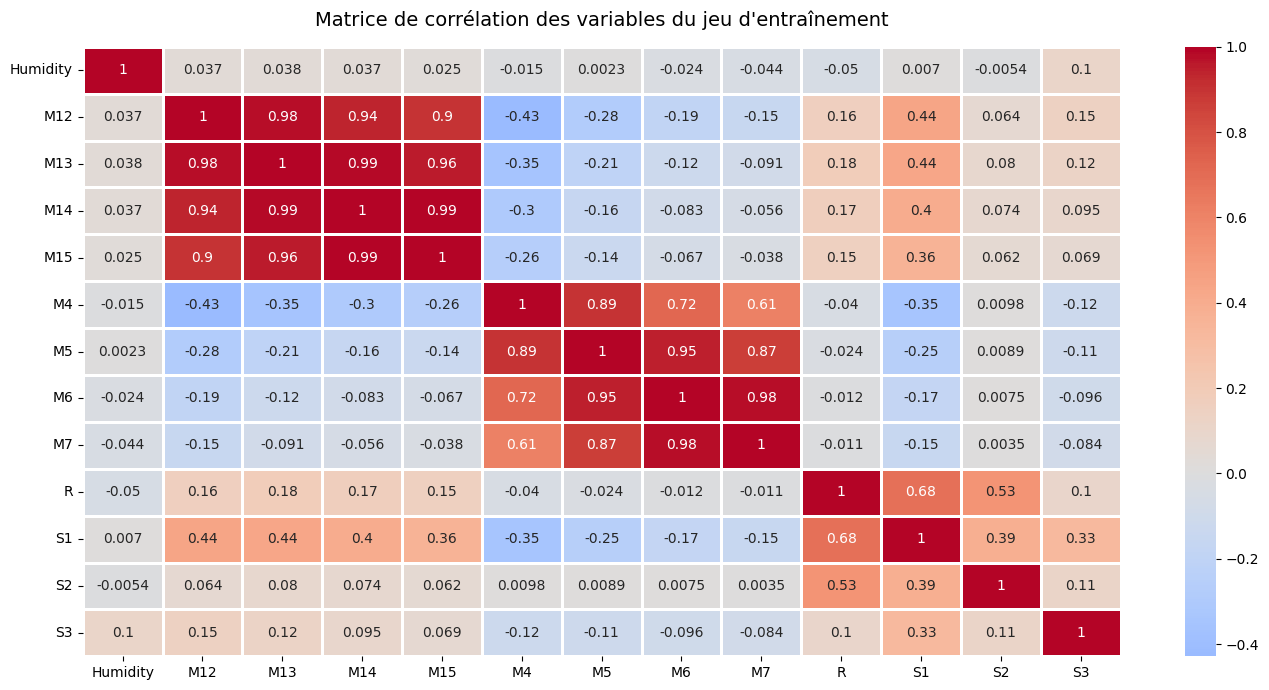

In [38]:
plt.figure(figsize=(14, 7))
sns.heatmap(X_without_id.corr(),annot=True,cmap='coolwarm',center = 0, linewidths=0.8)
plt.title("Matrice de corrélation des variables du jeu d'entraînement", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [39]:
zero_rate = (y_without_id == 0).sum() / len(y_without_id)
zero_rate = zero_rate.sort_values(ascending=False)

zero_rate_df = zero_rate.reset_index()
zero_rate_df.columns = ["Variable cible", "Proportion de zéros"]
zero_rate_df


,Variable cible,Proportion de zéros
0,c15,1.000000
1,c16,0.994210
2,c08,0.989612
3,c19,0.978328
4,c09,0.973582
5,c17,0.956163
6,c23,0.949545
7,c06,0.945095
8,c05,0.945095
9,c21,0.945095


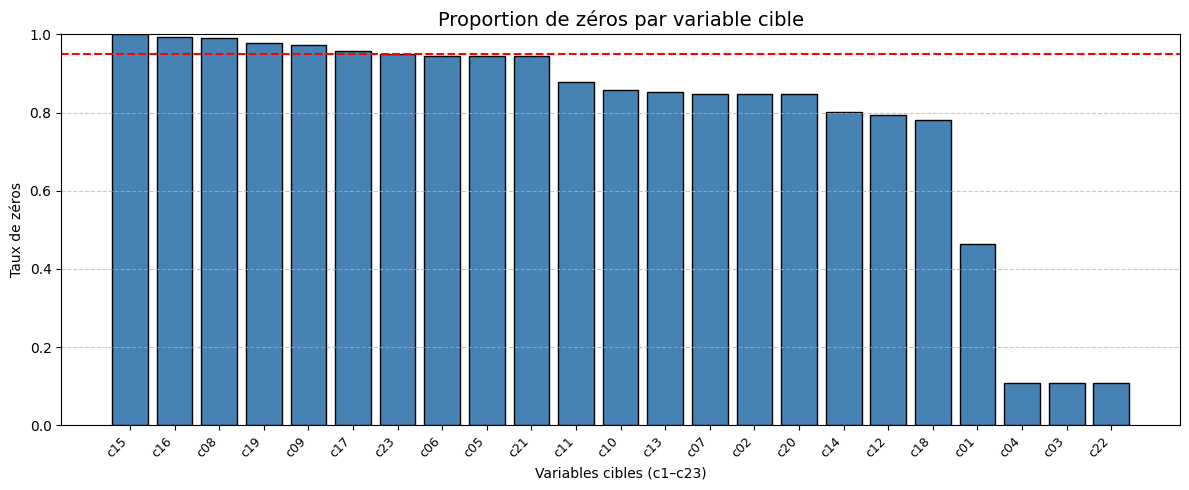

In [44]:
plt.figure(figsize=(12, 5))
plt.bar(
    zero_rate_df["Variable cible"],
    zero_rate_df["Proportion de zéros"],
    color='steelblue',
    edgecolor='black'
)
plt.title("Proportion de zéros par variable cible", fontsize=14)
plt.ylabel("Taux de zéros")
plt.xlabel("Variables cibles (c1–c23)")
plt.ylim(0, 1)
plt.axhline(y=0.95, color='r', linestyle='--', label='50% de zéros')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## Fonctions de préprocessing

In [45]:
def load_and_preprocess_data(x_train_path, y_train_path, x_test_path, zero_threshold=0.999999, pca_components=0.95):
    print("Chargement et prétraitement...")
    if not all(os.path.exists(p) for p in [x_train_path, y_train_path, x_test_path]):
        print("ERREUR: Fichiers de données introuvables.")
        return None, None, None, None, None, None
        
    X_train = pd.read_csv(x_train_path)
    X_test = pd.read_csv(x_test_path)
    y_train = pd.read_csv(y_train_path)

    test_id = X_test["ID"]
    X_train = X_train.drop(columns=["ID"])
    X_test = X_test.drop(columns=["ID"])
    y_train = y_train.drop(columns=["ID"], errors='ignore')

    zero_rate = (y_train == 0).sum() / len(y_train)
    removed_targets = zero_rate[zero_rate > zero_threshold].index.tolist()
    y_train_filtered = y_train.drop(columns=removed_targets)
    print(f"Suppression de {len(removed_targets)} cibles quasi nulles.")

    groups = {
        "M_group1": ["M4", "M5", "M6", "M7"],
        "M_group2": ["M12", "M13", "M14", "M15"],
        "S_group": ["S1", "S2", "S3", "R"]
    }

    X_train_pca, X_test_pca = X_train.copy(), X_test.copy()
    scaler = StandardScaler()
    
    for name, cols in groups.items():
        if not all(col in X_train.columns for col in cols): continue
            
        X_train_scaled = scaler.fit_transform(X_train[cols])
        X_test_scaled = scaler.transform(X_test[cols])
            
        pca = PCA(n_components=pca_components, random_state=42)
        train_comp = pca.fit_transform(X_train_scaled)
        test_comp = pca.transform(X_test_scaled)
        
        n_comp = pca.n_components_
        
        for i in range(n_comp):
            X_train_pca[f"{name}_PCA{i+1}"] = train_comp[:, i]
            X_test_pca[f"{name}_PCA{i+1}"] = test_comp[:, i]
        
        X_train_pca.drop(columns=cols, inplace=True)
        X_test_pca.drop(columns=cols, inplace=True)

    print(f"Shape finale X_train : {X_train_pca.shape}")
    return X_train_pca, X_test_pca, y_train_filtered, removed_targets, test_id, y_train.columns.tolist()



## Fonction de score 

In [46]:
def custom_metric(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f = np.where(y_true < 0.5, 1.0, 1.2) 
    errors = np.mean(f * (y_pred - y_true) ** 2, axis=1)
    return np.sqrt(np.mean(errors))


## Comparaison entre modèle simple pour détécter le meilleur

In [47]:
def compare_models(X_train, y_train, n_splits=5):
    """ Compare les modèles RFR, GBR et LGBMR en utilisant la Cross-Validation. """
    
    print(f"\nDémarrage de la comparaison de modèles ({n_splits} plis CV)...")
    models = {
        "RandomForestRegressor (RFR)": RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42),
        "LightGBM Regressor (LGBMR)": MultiOutputRegressor(
            LGBMRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
        ),
        "GradientBoostingRegressor (GBR)": MultiOutputRegressor(
            GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
        )
    }
    scorer = make_scorer(custom_metric, greater_is_better=False)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    results = {}
    
    for name, model in models.items():
        print(f"\nÉvaluation de: {name}...")
        cv_scores = -cross_val_score(
            estimator=model, 
            X=X_train, 
            y=y_train, 
            scoring=scorer, 
            cv=kf, 
            n_jobs=-1
        )
        mean_rmse = np.mean(cv_scores)
        results[name] = {
            "Mean_RMSE": mean_rmse
        }
        
        print(f"  Moyenne RMSE: {mean_rmse:.4f}")
    
    print("\nComparaison terminée.")
    results_df = pd.DataFrame(results).T.sort_values(by='Mean_RMSE')
    print("\n Tableau Récapitulatif des Performances (Le plus petit est le meilleur):")
    print(results_df.to_markdown(floatfmt=".4f"))
    best_model_name = results_df.index[0]
    return best_model_name, models[best_model_name]

In [ ]:
PCA_N_COMPONENTS = 0.99 

X_train_pca, X_test_pca, y_train_filtered, removed_targets, test_id, all_targets = load_and_preprocess_data(
    X_TRAIN_PATH, Y_TRAIN_PATH, X_TEST_PATH,
    zero_threshold=0.999999,
    pca_components=PCA_N_COMPONENTS
)

best_model_name, best_model_instance = compare_models(X_train_pca, y_train_filtered, n_splits=5)

print(f"\nLe meilleur modèle pour l'optimisation est : {best_model_name}")

## Fonction de création de la soumission

In [48]:
def create_submission(y_pred, removed_targets, y_train_columns, test_id, output_filename):
    
    active_targets = [c for c in y_train_columns if c not in removed_targets]
    y_pred_df = pd.DataFrame(y_pred, columns=active_targets)

    for col in removed_targets:
        y_pred_df[col] = 0.0

    target_cols_ordered = y_train_columns
    y_pred_df = y_pred_df[target_cols_ordered].reset_index(drop=True)
    test_id_series = test_id.reset_index(drop=True)

    y_pred_df.insert(0, 'ID', test_id_series)

    submission = y_pred_df
    submission.index.name = None

    submission.to_csv(output_filename, index=False)
    print(f"\nFichier de soumission **{output_filename}** créé avec succès.")

## Entrainement du randomforest par randomized search cv

In [ ]:
def train_random_forest_fast(X_train, y_train, subset_size=8000, n_iter=30, cv=5):
    print(f"\nLancement du RandomizedSearch (n_iter={n_iter}, cv={cv}) sur {min(subset_size, len(X_train))} échantillons...")
    
    X_subset = X_train.iloc[:min(subset_size, len(X_train)), :]
    y_subset = y_train.iloc[:min(subset_size, len(X_train)), :]
    
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    param_distributions = {
        'n_estimators': [50, 100, 200],         
        'max_depth': [8, 15, 25, None],        
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.8] 
    }

    scorer = make_scorer(custom_metric, greater_is_better=False)

    rs = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scorer,
        cv=cv,
        verbose=2,
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_subset, y_subset)
    print("RandomizedSearch terminé.")
    print("Meilleurs paramètres trouvés :", rs.best_params_)
    
    best_model = rs.best_estimator_
    print("Entraînement final sur tout X_train...")
    best_model.fit(X_train, y_train)
    return best_model

def evaluate_with_cross_validation(model, X_train, y_train, n_splits=5):
    """ Évaluation par K-Fold Cross-Validation (RMSE moyenne). """
    print(f"\nDémarrage de la Cross-Validation ({n_splits} plis)...")
    
    scorer = make_scorer(custom_metric, greater_is_better=False)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    cv_scores = -cross_val_score(
        estimator=model, 
        X=X_train, 
        y=y_train, 
        scoring=scorer, 
        cv=kf, 
        n_jobs=-1
    )
    
    print("Cross-Validation terminée.")
    print(f"Moyenne des scores (RMSE) : **{np.mean(cv_scores):.4f}** (± {np.std(cv_scores):.4f})")
    
    return np.mean(cv_scores), np.std(cv_scores)

In [ ]:
PCA_N_COMPONENTS = 0.99 
X_train_pca, X_test_pca, y_train_filtered, removed_targets, test_id, all_targets = load_and_preprocess_data(
    X_TRAIN_PATH, Y_TRAIN_PATH, X_TEST_PATH,
    zero_threshold=0.999999,
    pca_components=PCA_N_COMPONENTS
)
model = train_random_forest_fast(X_train_pca, y_train_filtered)
mean_rmse, std_rmse = evaluate_with_cross_validation(model, X_train_pca, y_train_filtered, n_splits=5)
print("Prédiction sur les données de test...")
y_pred = model.predict(X_test_pca)

create_submission(y_pred, removed_targets, all_targets, test_id, "submission_final.csv")

Chargement et prétraitement...
Suppression de 1 cibles quasi nulles.
Shape finale X_train : (202933, 9)

Lancement du RandomizedSearch (n_iter=30, cv=5) sur 8000 échantillons...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   2.0s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   2.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   2.2s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   2.2s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=50; total time=   2.2s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   2.3s
[CV] END max_depth=15, max_features=log2,